In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('dragon_data.csv')

# Initial exploration
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nSummary statistics:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())
print("\nSpecies distribution:")
print(df['SPC'].value_counts())

# Check for the negative age (data quality issue spotted!)
print("\nAge range:", df['AGE'].min(), "to", df['AGE'].max())

Dataset shape: (500, 7)

First few rows:
      SPC   AGE     MASS   WSP   HID     SPD   FHO
0  Wyvern    16     1304   4.0  4.83    4800   611
1  Dragon  2726  3693174  52.0  4.82  114400  1960
2  Dragon   377   154201  19.4  4.61   42680  1123
3   Hydra   169    40146  13.0  2.65    7800   706
4  Dragon  1571  1549315  39.6  1.49   87120  1441

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPC     500 non-null    object 
 1   AGE     500 non-null    int64  
 2   MASS    500 non-null    int64  
 3   WSP     500 non-null    float64
 4   HID     500 non-null    float64
 5   SPD     500 non-null    int64  
 6   FHO     500 non-null    int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 27.5+ KB
None

Summary statistics:
              AGE          MASS         WSP         HID            SPD  \
count   500.00000  5.000000e+02  500.0

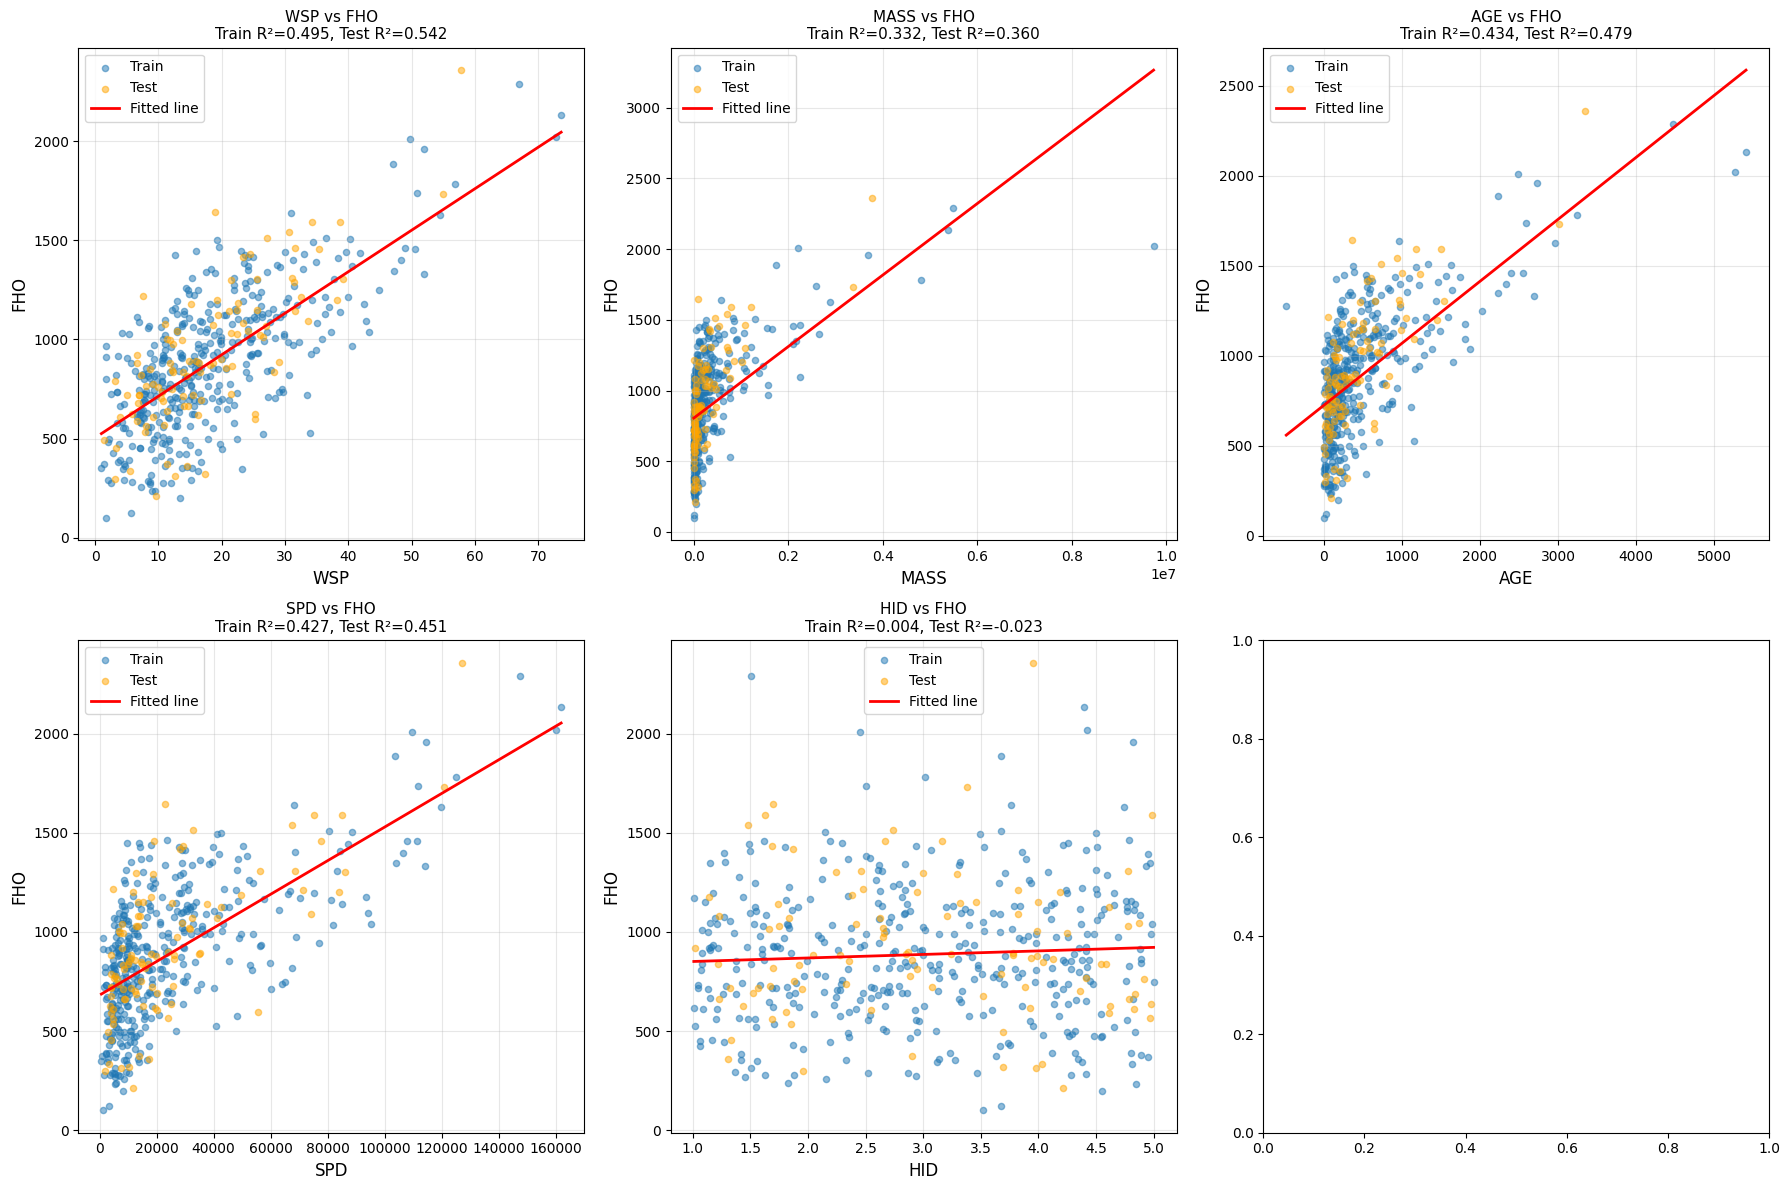


--------------------------------------------------------------------------------
Single variable regression results
--------------------------------------------------------------------------------
      train_r2  test_r2  test_rmse  test_mae  coefficient  intercept
WSP     0.4947   0.5417   240.1450  181.3241      20.9388   503.8663
MASS    0.3317   0.3601   283.7564  221.5388       0.0003   805.4770
AGE     0.4336   0.4787   256.1110  197.0786       0.3443   724.9891
SPD     0.4274   0.4511   262.8068  198.5143       0.0085   681.4393
HID     0.0035  -0.0231   358.7800  272.2490      17.7803   832.8836


In [ ]:
# Split data into train and test sets
X = df[['WSP', 'MASS', 'AGE', 'SPD', 'HID']]
y = df['FHO']

# Handle the categorical variable SPC separately
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Store results
single_var_results = {}

# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Variables to test
variables = ['WSP', 'MASS', 'AGE', 'SPD', 'HID']

for idx, var in enumerate(variables):
    # Prepare data
    X_train_var = X_train[[var]]
    X_test_var = X_test[[var]]

    # Fit model
    model = LinearRegression()
    model.fit(X_train_var, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_var)
    y_test_pred = model.predict(X_test_var)

    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)

    # Store results
    single_var_results[var] = {
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'coefficient': model.coef_[0],
        'intercept': model.intercept_
    }

    # Plot
    ax = axes[idx]
    ax.scatter(X_train_var, y_train, alpha=0.5, label='Train', s=20)
    ax.scatter(X_test_var, y_test, alpha=0.5, label='Test', s=20, color='orange')

    # Plot regression line
    X_range = np.linspace(X_train_var.min(), X_train_var.max(), 100).reshape(-1, 1)
    y_range = model.predict(X_range)
    ax.plot(X_range, y_range, 'r-', linewidth=2, label='Fitted line')

    ax.set_xlabel(var, fontsize=12)
    ax.set_ylabel('FHO', fontsize=12)
    ax.set_title(f'{var} vs FHO\nTrain R²={train_r2:.3f}, Test R²={test_r2:.3f}',
                 fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('single_variable_regression.png', dpi=300, bbox_inches='tight')
plt.show()

# Print results table
print("\n" + "-"*80)
print("Single variable regression results")
print("-"*80)
results_df = pd.DataFrame(single_var_results).T
print(results_df.round(4))


Species Model:
Train R²: 0.1727
Test R²: 0.0892
Coefficients: Hydra=-390.41, Wyvern=-223.26
Intercept (Dragon baseline): 1138.14


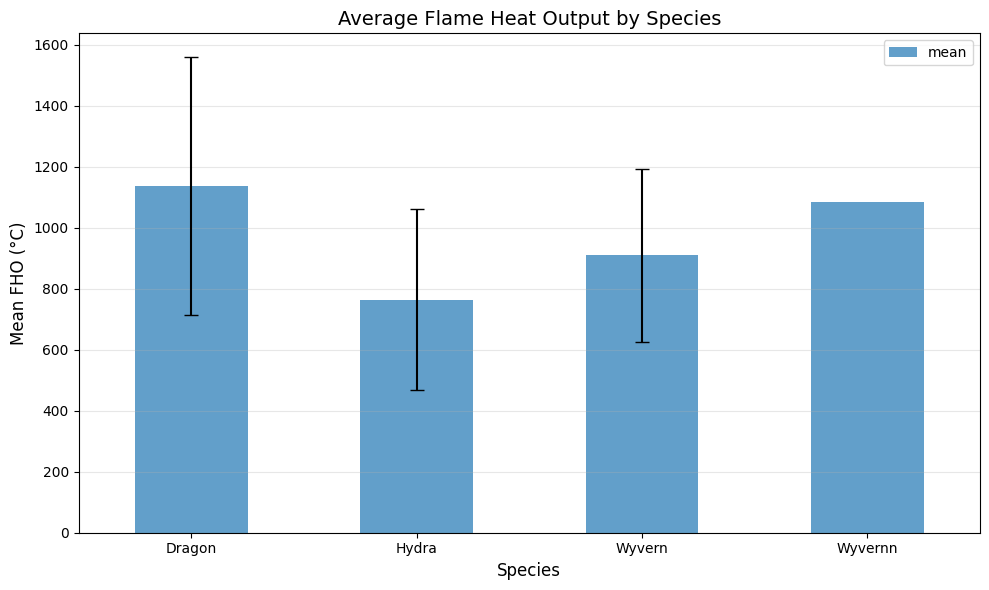


Species Statistics:
                mean         std  count
SPC                                    
Dragon   1136.764706  423.042075    102
Hydra     764.046729  297.570282    214
Wyvern    910.289617  283.705791    183
Wyvernn  1083.000000         NaN      1


In [ ]:
# Create dummy variables for species
df_with_dummies = pd.get_dummies(df, columns=['SPC'], drop_first=True)

# Split including species
X_species = df_with_dummies[['SPC_Hydra', 'SPC_Wyvern']]
X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(
    X_species, df['FHO'], test_size=0.2, random_state=42
)

# Fit model
model_species = LinearRegression()
model_species.fit(X_train_sp, y_train_sp)

# Predictions
y_train_pred_sp = model_species.predict(X_train_sp)
y_test_pred_sp = model_species.predict(X_test_sp)

# Metrics
train_r2_sp = r2_score(y_train_sp, y_train_pred_sp)
test_r2_sp = r2_score(y_test_sp, y_test_pred_sp)

print(f"\nSpecies Model:")
print(f"Train R²: {train_r2_sp:.4f}")
print(f"Test R²: {test_r2_sp:.4f}")
print(f"Coefficients: Hydra={model_species.coef_[0]:.2f}, "
      f"Wyvern={model_species.coef_[1]:.2f}")
print(f"Intercept (Dragon baseline): {model_species.intercept_:.2f}")

# Visualize species effect
fig, ax = plt.subplots(figsize=(10, 6))
species_means = df.groupby('SPC')['FHO'].agg(['mean', 'std', 'count'])
species_means.plot(kind='bar', y='mean', yerr='std', ax=ax, capsize=5, alpha=0.7)
ax.set_ylabel('Mean FHO (°C)', fontsize=12)
ax.set_xlabel('Species', fontsize=12)
ax.set_title('Average Flame Heat Output by Species', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('species_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSpecies Statistics:")
print(species_means)

In [ ]:
#Number 2


----------------------------------------------------------------------------------------------------
Multiple Variable Regression comparison
----------------------------------------------------------------------------------------------------
                             N Features  Train R²  Test R²  Adj R² (test)  \
Model 1: All Numeric                5.0    0.4999   0.5444         0.5202   
Model 2: Top 3 Variables            3.0    0.4971   0.5431         0.5288   
Model 3: Physical Features          3.0    0.4959   0.5391         0.5247   
Model 4: All with Species           7.0    0.5026   0.5401         0.5051   
Model 5: Selected + Species         4.0    0.4994   0.5424         0.5231   

                                 RMSE       MAE  Overfit Gap  
Model 1: All Numeric         239.4220  180.0665      -0.0446  
Model 2: Top 3 Variables     239.7601  180.5162      -0.0461  
Model 3: Physical Features   240.8071  181.1017      -0.0432  
Model 4: All with Species    240.5425  181

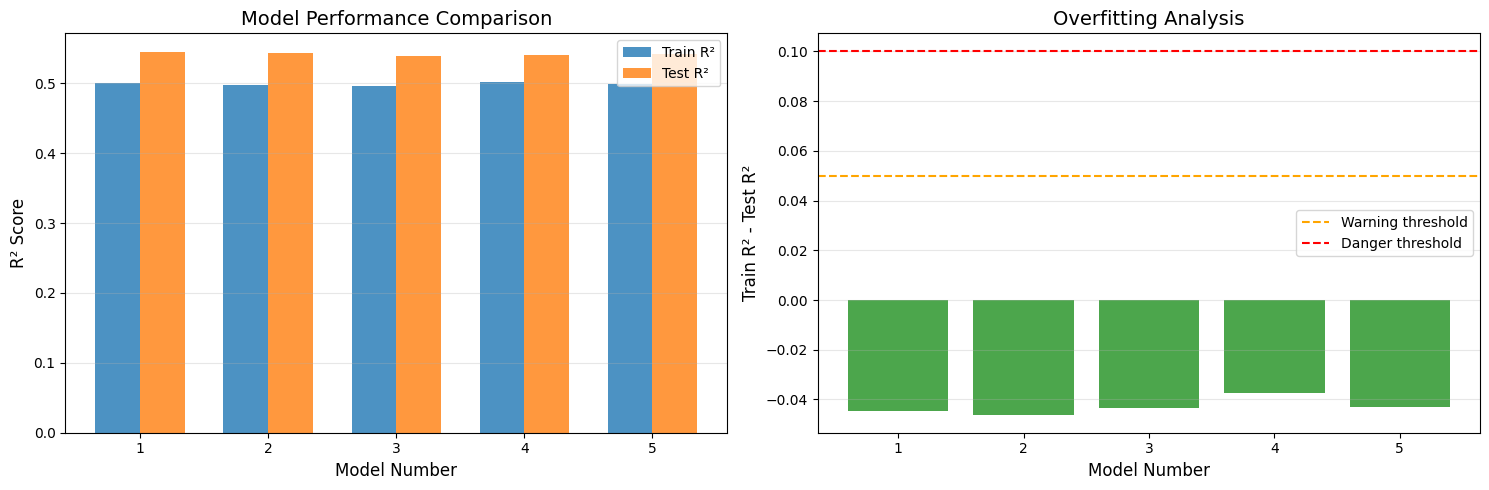

In [ ]:
# Define different model configurations
model_configs = {
    'Model 1: All Numeric': ['WSP', 'MASS', 'AGE', 'SPD', 'HID'],
    'Model 2: Top 3 Variables': ['WSP', 'MASS', 'AGE'],  # Adjust based on your findings
    'Model 3: Physical Features': ['WSP', 'MASS', 'HID'],
    'Model 4: All with Species': ['WSP', 'MASS', 'AGE', 'SPD', 'HID', 'SPC_Hydra', 'SPC_Wyvern'],
    'Model 5: Selected + Species': ['WSP', 'AGE', 'SPC_Hydra', 'SPC_Wyvern'],
}

# Prepare full dataset with dummies
X_full = df_with_dummies.drop(['FHO'], axis=1)
y_full = df_with_dummies['FHO']

# Remove the species text column if it exists
if 'SPC' in X_full.columns:
    X_full = X_full.drop('SPC', axis=1)

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# Store results
multi_var_results = {}

for model_name, features in model_configs.items():
    # Select features
    X_train_model = X_train_full[features]
    X_test_model = X_test_full[features]

    # Fit model
    model = LinearRegression()
    model.fit(X_train_model, y_train_full)

    # Predictions
    y_train_pred = model.predict(X_train_model)
    y_test_pred = model.predict(X_test_model)

    # Metrics
    train_r2 = r2_score(y_train_full, y_train_pred)
    test_r2 = r2_score(y_test_full, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test_full, y_test_pred))
    test_mae = mean_absolute_error(y_test_full, y_test_pred)

    # Calculate Adjusted R²
    n = len(y_train_full)
    p = len(features)
    adj_r2_train = 1 - (1 - train_r2) * (n - 1) / (n - p - 1)

    n_test = len(y_test_full)
    adj_r2_test = 1 - (1 - test_r2) * (n_test - 1) / (n_test - p - 1)

    multi_var_results[model_name] = {
        'features': features,
        'n_features': len(features),
        'train_r2': train_r2,
        'test_r2': test_r2,
        'adj_r2_train': adj_r2_train,
        'adj_r2_test': adj_r2_test,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'overfitting': train_r2 - test_r2,
        'coefficients': dict(zip(features, model.coef_)),
        'intercept': model.intercept_
    }

# Print comparison
print("\n" + "-"*100)
print("Multiple Variable Regression comparison")
print("-"*100)

comparison_df = pd.DataFrame({
    name: {
        'N Features': results['n_features'],
        'Train R²': results['train_r2'],
        'Test R²': results['test_r2'],
        'Adj R² (test)': results['adj_r2_test'],
        'RMSE': results['test_rmse'],
        'MAE': results['test_mae'],
        'Overfit Gap': results['overfitting']
    }
    for name, results in multi_var_results.items()
}).T

print(comparison_df.round(4))

# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R² comparison
ax1 = axes[0]
x_pos = np.arange(len(multi_var_results))
train_r2s = [r['train_r2'] for r in multi_var_results.values()]
test_r2s = [r['test_r2'] for r in multi_var_results.values()]

width = 0.35
ax1.bar(x_pos - width/2, train_r2s, width, label='Train R²', alpha=0.8)
ax1.bar(x_pos + width/2, test_r2s, width, label='Test R²', alpha=0.8)
ax1.set_ylabel('R² Score', fontsize=12)
ax1.set_title('Model Performance Comparison', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(range(1, len(multi_var_results)+1))
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xlabel('Model Number', fontsize=12)

# Overfitting analysis
ax2 = axes[1]
overfitting = [r['overfitting'] for r in multi_var_results.values()]
colors = ['green' if x < 0.05 else 'orange' if x < 0.1 else 'red' for x in overfitting]
ax2.bar(x_pos, overfitting, color=colors, alpha=0.7)
ax2.axhline(y=0.05, color='orange', linestyle='--', label='Warning threshold')
ax2.axhline(y=0.1, color='red', linestyle='--', label='Danger threshold')
ax2.set_ylabel('Train R² - Test R²', fontsize=12)
ax2.set_title('Overfitting Analysis', fontsize=14)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(range(1, len(multi_var_results)+1))
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xlabel('Model Number', fontsize=12)

plt.tight_layout()
plt.savefig('multiple_regression_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Number 3

In [ ]:
print("\n" + "-"*80)
print("Model comparison analysis")
print("-"*80)

# Find best model
best_model_name = max(multi_var_results.keys(),
                      key=lambda x: multi_var_results[x]['test_r2'])
best_model = multi_var_results[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"Test R²: {best_model['test_r2']:.4f}")
print(f"Test RMSE: {best_model['test_rmse']:.2f}°C")
print(f"Overfitting Gap: {best_model['overfitting']:.4f}")

# Analyze whether adding variables helps
print("\n" + "-"*80)
print("Incremental value of adding variables:")
print("-"*80)

for i, (name, results) in enumerate(multi_var_results.items()):
    print(f"\n{name}:")
    print(f"  Features: {', '.join(results['features'])}")
    print(f"  Test R²: {results['test_r2']:.4f}")
    print(f"  Adjusted R² (test): {results['adj_r2_test']:.4f}")
    if i > 0:
        prev_results = list(multi_var_results.values())[i-1]
        improvement = results['test_r2'] - prev_results['test_r2']
        print(f"  Improvement over previous: {improvement:+.4f}")

# Overfitting check
print("\n" + "-"*80)
print("Overfitting assessment:")
print("-"*80)

for name, results in multi_var_results.items():
    gap = results['overfitting']
    if gap < 0.02:
        status = "Excellent - No overfitting"
    elif gap < 0.05:
        status = "Good - Minimal overfitting"
    elif gap < 0.1:
        status = "Warning - Some overfitting"
    else:
        status = "Poor - Significant overfitting"

    print(f"{name}: Gap = {gap:.4f} - {status}")

# Recommendation
print("\n" + "-"*80)
print("Recommendation:")
print("-"*80)
print(f"""
Based on the analysis, I recommend {best_model_name} because:
1. It achieves strong test performance (R² = {best_model['test_r2']:.4f})
2. It shows {'minimal' if best_model['overfitting'] < 0.05 else 'acceptable'} overfitting
3. It uses {best_model['n_features']} features, providing a good balance
4. The adjusted R² ({best_model['adj_r2_test']:.4f}) confirms genuine predictive power
""")


--------------------------------------------------------------------------------
Model comparison analysis
--------------------------------------------------------------------------------

Best Model: Model 1: All Numeric
Test R²: 0.5444
Test RMSE: 239.42°C
Overfitting Gap: -0.0446

--------------------------------------------------------------------------------
Incremental value of adding variables:
--------------------------------------------------------------------------------

Model 1: All Numeric:
  Features: WSP, MASS, AGE, SPD, HID
  Test R²: 0.5444
  Adjusted R² (test): 0.5202

Model 2: Top 3 Variables:
  Features: WSP, MASS, AGE
  Test R²: 0.5431
  Adjusted R² (test): 0.5288
  Improvement over previous: -0.0013

Model 3: Physical Features:
  Features: WSP, MASS, HID
  Test R²: 0.5391
  Adjusted R² (test): 0.5247
  Improvement over previous: -0.0040

Model 4: All with Species:
  Features: WSP, MASS, AGE, SPD, HID, SPC_Hydra, SPC_Wyvern
  Test R²: 0.5401
  Adjusted R² (test): 0

In [ ]:
#Number 4


--------------------------------------------------------------------------------
Coefficient interpretation
--------------------------------------------------------------------------------

Intercept: 478.45°C

Coefficients (sorted by absolute magnitude):
Feature  Coefficient  Abs_Coefficient
    WSP    21.835338        21.835338
    HID     6.281565         6.281565
    AGE    -0.155807         0.155807
    SPD     0.001652         0.001652
   MASS     0.000073         0.000073

--------------------------------------------------------------------------------
Standardized coefficients (for comparing importance):
--------------------------------------------------------------------------------
Feature  Standardized_Coefficient  Importance_Rank
    WSP                255.604908                1
    AGE               -103.840972                2
   MASS                 57.869406                3
    SPD                 44.417457                4
    HID                  7.319972          

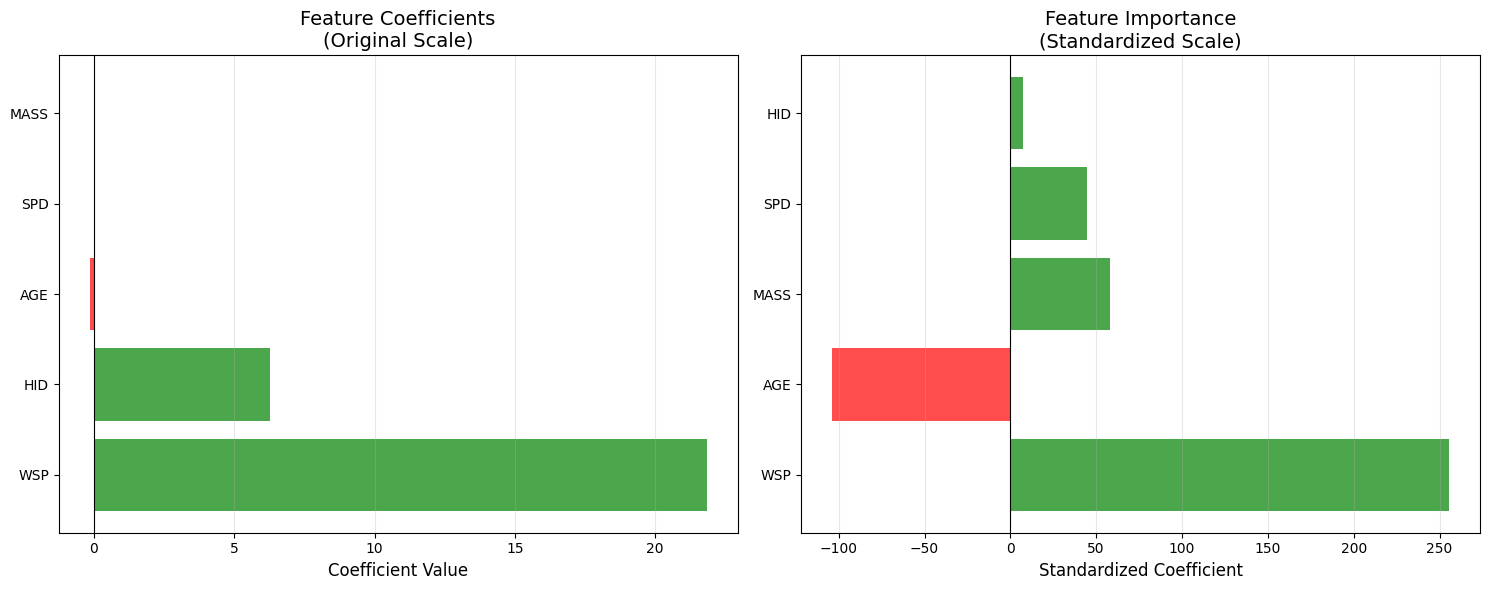


--------------------------------------------------------------------------------
Biological interpretation:
--------------------------------------------------------------------------------

WSP: +21.8353
 Each unit increase in WSP increases FHO by 21.84°C
 Biological context: Wingspan affects flame distribution and oxygen intake during flame production

MASS: +0.0001
 Each unit increase in MASS increases FHO by 0.00°C
 Biological context: Larger dragons have bigger flame sacs and can produce more intense flames

AGE: -0.1558
 Each unit increase in AGE decreases FHO by 0.16°C
 Biological context: Older dragons have developed stronger flame control and intensity

SPD: +0.0017
 Each unit increase in SPD increases FHO by 0.00°C
 Biological context: Flight speed correlates with lung capacity and metabolic rate

HID: +6.2816
 Each unit increase in HID increases FHO by 6.28°C
 Biological context: Hide thickness may reflect overall physical development


In [ ]:
# Use the best model for interpretation
best_features = best_model['features']
X_train_best = X_train_full[best_features]
X_test_best = X_test_full[best_features]

# Refit to get the model object
final_model = LinearRegression()
final_model.fit(X_train_best, y_train_full)

# Coefficient analysis
print("\n" + "-"*80)
print("Coefficient interpretation")
print("-"*80)

coef_df = pd.DataFrame({
    'Feature': best_features,
    'Coefficient': final_model.coef_,
    'Abs_Coefficient': np.abs(final_model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print(f"\nIntercept: {final_model.intercept_:.2f}°C")
print("\nCoefficients (sorted by absolute magnitude):")
print(coef_df.to_string(index=False))

# Standardized coefficients for fair comparison
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_best)
X_test_scaled = scaler.transform(X_test_best)

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train_full)

std_coef_df = pd.DataFrame({
    'Feature': best_features,
    'Standardized_Coefficient': model_scaled.coef_,
    'Importance_Rank': range(1, len(best_features)+1)
}).sort_values('Standardized_Coefficient', key=abs, ascending=False)
std_coef_df['Importance_Rank'] = range(1, len(best_features)+1)

print("\n" + "-"*80)
print("Standardized coefficients (for comparing importance):")
print("-"*80)
print(std_coef_df.to_string(index=False))

# Visualize coefficients
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Regular coefficients
ax1 = axes[0]
colors = ['green' if x > 0 else 'red' for x in coef_df['Coefficient']]
ax1.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_xlabel('Coefficient Value', fontsize=12)
ax1.set_title('Feature Coefficients\n(Original Scale)', fontsize=14)
ax1.grid(True, alpha=0.3, axis='x')

# Standardized coefficients
ax2 = axes[1]
colors = ['green' if x > 0 else 'red' for x in std_coef_df['Standardized_Coefficient']]
ax2.barh(std_coef_df['Feature'], std_coef_df['Standardized_Coefficient'],
         color=colors, alpha=0.7)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Standardized Coefficient', fontsize=12)
ax2.set_title('Feature Importance\n(Standardized Scale)', fontsize=14)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('coefficient_interpretation.png', dpi=300, bbox_inches='tight')
plt.show()

# Biological interpretation
print("\n" + "-"*80)
print("Biological interpretation:")
print("-"*80)

interpretations = {
    'WSP': 'Wingspan affects flame distribution and oxygen intake during flame production',
    'MASS': 'Larger dragons have bigger flame sacs and can produce more intense flames',
    'AGE': 'Older dragons have developed stronger flame control and intensity',
    'SPD': 'Flight speed correlates with lung capacity and metabolic rate',
    'HID': 'Hide thickness may reflect overall physical development',
    'SPC_Hydra': 'Hydras have different flame biology compared to Dragons (baseline)',
    'SPC_Wyvern': 'Wyverns have different flame biology compared to Dragons (baseline)'
}

for feat in best_features:
    coef_val = best_model['coefficients'][feat]
    direction = "increases" if coef_val > 0 else "decreases"
    print(f"\n{feat}: {coef_val:+.4f}")
    print(f" Each unit increase in {feat} {direction} FHO by {abs(coef_val):.2f}°C")
    if feat in interpretations:
        print(f" Biological context: {interpretations[feat]}")

In [ ]:
#Number 5


--------------------------------------------------------------------------------
Residual analysis
--------------------------------------------------------------------------------

Training Set:
  Mean residual: 0.0000°C (should be ≈0)
  Std of residuals: 246.46°C
  RMSE: 246.46°C

Test Set:
  Mean residual: 45.0926°C (should be ≈0)
  Std of residuals: 235.14°C
  RMSE: 239.42°C
  MAE: 180.07°C


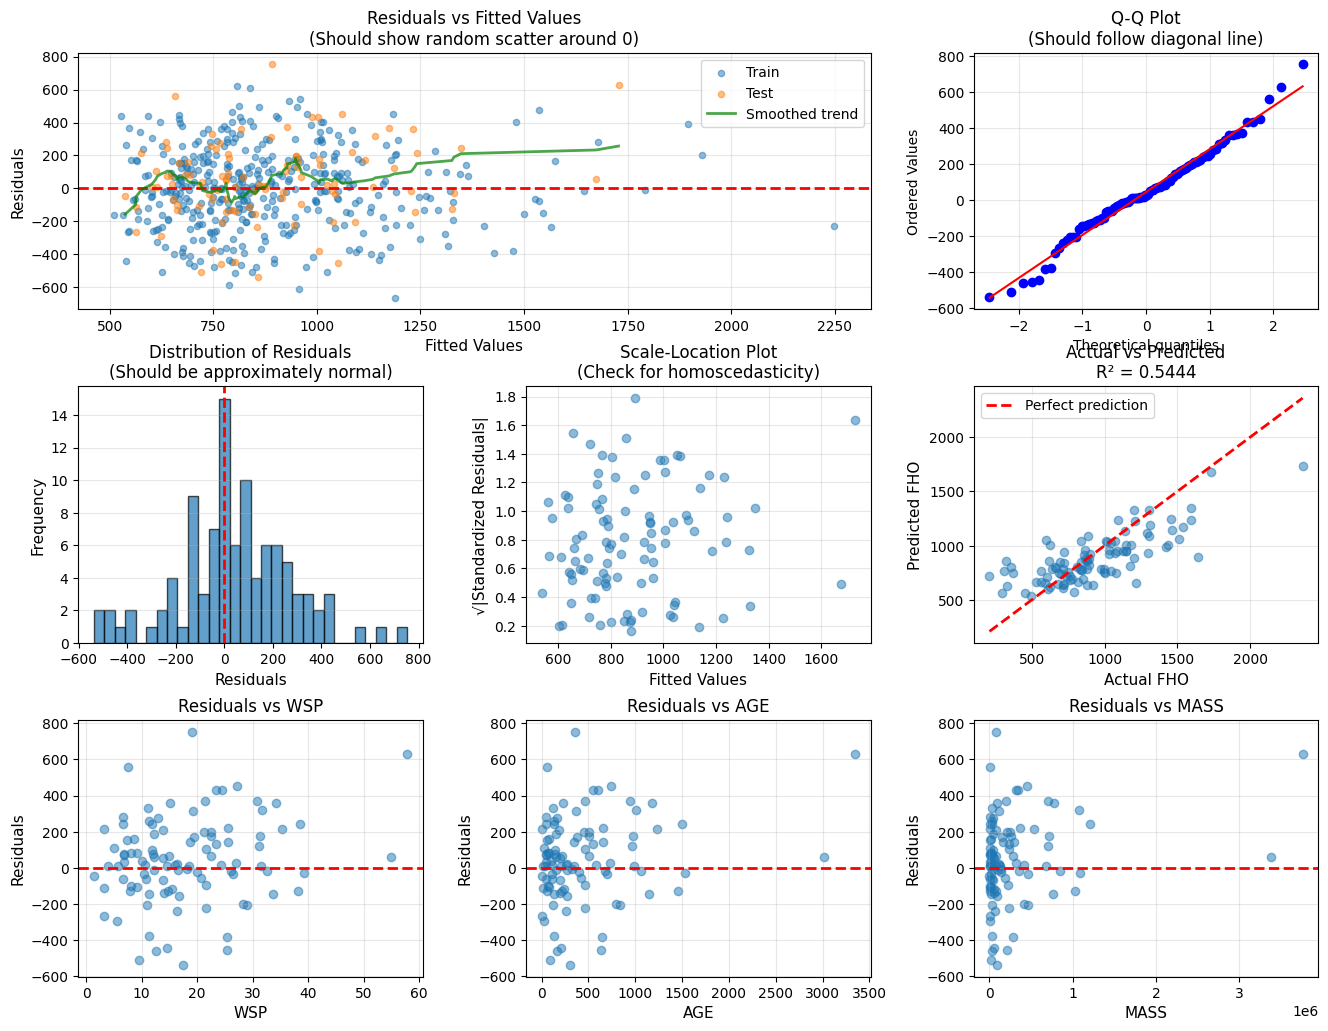


--------------------------------------------------------------------------------
Statistical diagnostics:
--------------------------------------------------------------------------------

Normality Test (D'Agostino-Pearson):
  p-value: 0.3757
  Result:  Residuals appear normal

Homoscedasticity Test (Levene's Test):
  p-value: 0.3125
  Result:  Variance appears constant

Durbin-Watson Test (autocorrelation):
  Statistic: 1.5884 (2.0 indicates no autocorrelation)
  Result:  No significant autocorrelation

Error Distribution:
  25th percentile: 58.38°C
  50th percentile (median): 140.57°C
  75th percentile: 247.57°C
  95th percentile: 459.75°C

95% Prediction Interval: ±460.87°C
This means we expect 95% of predictions to be within ±460.87°C of the true value


In [ ]:
# Detailed residual analysis
y_train_pred_final = final_model.predict(X_train_best)
y_test_pred_final = final_model.predict(X_test_best)

train_residuals = (y_train_full - y_train_pred_final).to_numpy()
test_residuals = (y_test_full - y_test_pred_final).to_numpy()

print("\n" + "-"*80)
print("Residual analysis")
print("-"*80)

print(f"\nTraining Set:")
print(f"  Mean residual: {np.mean(train_residuals):.4f}°C (should be \u22480)")
print(f"  Std of residuals: {np.std(train_residuals):.2f}°C")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train_full, y_train_pred_final)):.2f}°C")

print(f"\nTest Set:")
print(f"  Mean residual: {np.mean(test_residuals):.4f}°C (should be \u22480)")
print(f"  Std of residuals: {np.std(test_residuals):.2f}°C")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_full, y_test_pred_final)):.2f}°C")
print(f"  MAE: {mean_absolute_error(y_test_full, y_test_pred_final):.2f}°C")

# Comprehensive residual plots
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Residuals vs Fitted
ax1 = fig.add_subplot(gs[0, :2])
ax1.scatter(y_train_pred_final, train_residuals, alpha=0.5, s=20, label='Train')
ax1.scatter(y_test_pred_final, test_residuals, alpha=0.5, s=20, label='Test')
ax1.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax1.set_xlabel('Fitted Values', fontsize=11)
ax1.set_ylabel('Residuals', fontsize=11)
ax1.set_title('Residuals vs Fitted Values\n(Should show random scatter around 0)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add smoothed line to check for patterns
from scipy.signal import savgol_filter
sorted_idx = np.argsort(y_test_pred_final)
if len(sorted_idx) > 50:
    window = min(51, len(sorted_idx)//3)
    if window % 2 == 0:
        window += 1
    smoothed = savgol_filter(test_residuals[sorted_idx], window, 3)
    ax1.plot(y_test_pred_final[sorted_idx], smoothed, 'g-', linewidth=2,
             label='Smoothed trend', alpha=0.7)
    ax1.legend()

# 2. Q-Q Plot
ax2 = fig.add_subplot(gs[0, 2])
from scipy import stats
stats.probplot(test_residuals, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot\n(Should follow diagonal line)', fontsize=12)
ax2.grid(True, alpha=0.3)

# 3. Histogram of residuals
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(test_residuals, bins=30, edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax3.set_xlabel('Residuals', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Distribution of Residuals\n(Should be approximately normal)', fontsize=12)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Scale-Location plot (Spread-Location)
ax4 = fig.add_subplot(gs[1, 1])
standardized_residuals = test_residuals / np.std(test_residuals)
ax4.scatter(y_test_pred_final, np.sqrt(np.abs(standardized_residuals)), alpha=0.5)
ax4.set_xlabel('Fitted Values', fontsize=11)
ax4.set_ylabel('\u221a|Standardized Residuals|', fontsize=11)
ax4.set_title('Scale-Location Plot\n(Check for homoscedasticity)', fontsize=12)
ax4.grid(True, alpha=0.3)

# 5. Actual vs Predicted
ax5 = fig.add_subplot(gs[1, 2])
ax5.scatter(y_test_full, y_test_pred_final, alpha=0.5)
min_val = min(y_test_full.min(), np.min(y_test_pred_final))
max_val = max(y_test_full.max(), np.max(y_test_pred_final))
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
ax5.set_xlabel('Actual FHO', fontsize=11)
ax5.set_ylabel('Predicted FHO', fontsize=11)
ax5.set_title(f'Actual vs Predicted\nR\u00b2 = {r2_score(y_test_full, y_test_pred_final):.4f}',
              fontsize=12)
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6-8. Residuals vs each important feature
important_features = std_coef_df.head(3)['Feature'].tolist()
for idx, feat in enumerate(important_features):
    ax = fig.add_subplot(gs[2, idx])
    if feat in X_test_best.columns:
        ax.scatter(X_test_best[feat], test_residuals, alpha=0.5)
        ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
        ax.set_xlabel(feat, fontsize=11)
        ax.set_ylabel('Residuals', fontsize=11)
        ax.set_title(f'Residuals vs {feat}', fontsize=12)
        ax.grid(True, alpha=0.3)

plt.savefig('comprehensive_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical tests
print("\n" + "-"*80)
print("Statistical diagnostics:")
print("-"*80)

# Normality test
from scipy.stats import shapiro, normaltest
statistic, p_value = normaltest(test_residuals)
print(f"\nNormality Test (D'Agostino-Pearson):")
print(f"  p-value: {p_value:.4f}")
print(f"  Result: {' Residuals appear normal' if p_value > 0.05 else ' Residuals may not be normal'}")

# Homoscedasticity test (Breusch-Pagan would be ideal, but we'll use a simpler approach)
# Split residuals into groups based on fitted values
median_fitted = np.median(y_test_pred_final)
low_group = test_residuals[y_test_pred_final <= median_fitted]
high_group = test_residuals[y_test_pred_final > median_fitted]

from scipy.stats import levene
statistic, p_value = levene(low_group, high_group)
print(f"\nHomoscedasticity Test (Levene's Test):")
print(f"  p-value: {p_value:.4f}")
print(f"  Result: {' Variance appears constant' if p_value > 0.05 else ' Heteroscedasticity may be present'}")

# Autocorrelation check
from statsmodels.stats.stattools import durbin_watson
dw_statistic = durbin_watson(test_residuals)
print(f"\nDurbin-Watson Test (autocorrelation):")
print(f"  Statistic: {dw_statistic:.4f} (2.0 indicates no autocorrelation)")
print(f"  Result: {' No significant autocorrelation' if 1.5 < dw_statistic < 2.5 else ' Possible autocorrelation'}")

# Error percentiles
print(f"\nError Distribution:")
print(f"  25th percentile: {np.percentile(np.abs(test_residuals), 25):.2f}°C")
print(f"  50th percentile (median): {np.percentile(np.abs(test_residuals), 50):.2f}°C")
print(f"  75th percentile: {np.percentile(np.abs(test_residuals), 75):.2f}°C")
print(f"  95th percentile: {np.percentile(np.abs(test_residuals), 95):.2f}°C")

# Calculate prediction intervals
pred_std = np.std(test_residuals)
print(f"\n95% Prediction Interval: \u00b1{1.96 * pred_std:.2f}°C")
print(f"This means we expect 95% of predictions to be within \u00b1{1.96 * pred_std:.2f}°C of the true value")

In [ ]:
#Number 6


--------------------------------------------------------------------------------
Feature engineering
--------------------------------------------------------------------------------

Checking skewness of variables (after initial cleaning):
  MASS: 6.65
    → Created log_MASS (skewness reduced to -0.74)
  AGE: 3.61
    → Created log_AGE (skewness reduced to -0.68)
  WSP: 1.39
    → Created log_WSP (skewness reduced to -0.48)

--------------------------------------------------------------------------------
Original features: 7
Engineered features: 22
New features created: 15

--------------------------------------------------------------------------------
FEATURE ENGINEERING RESULTS
--------------------------------------------------------------------------------
                      N Features  Train R²  Test R²      RMSE  Overfit Gap
Original Best Model          5.0    0.4992   0.5446  239.3709      -0.0454
With Log Transforms          8.0    0.5113   0.5632  234.4246      -0.0520
Wit

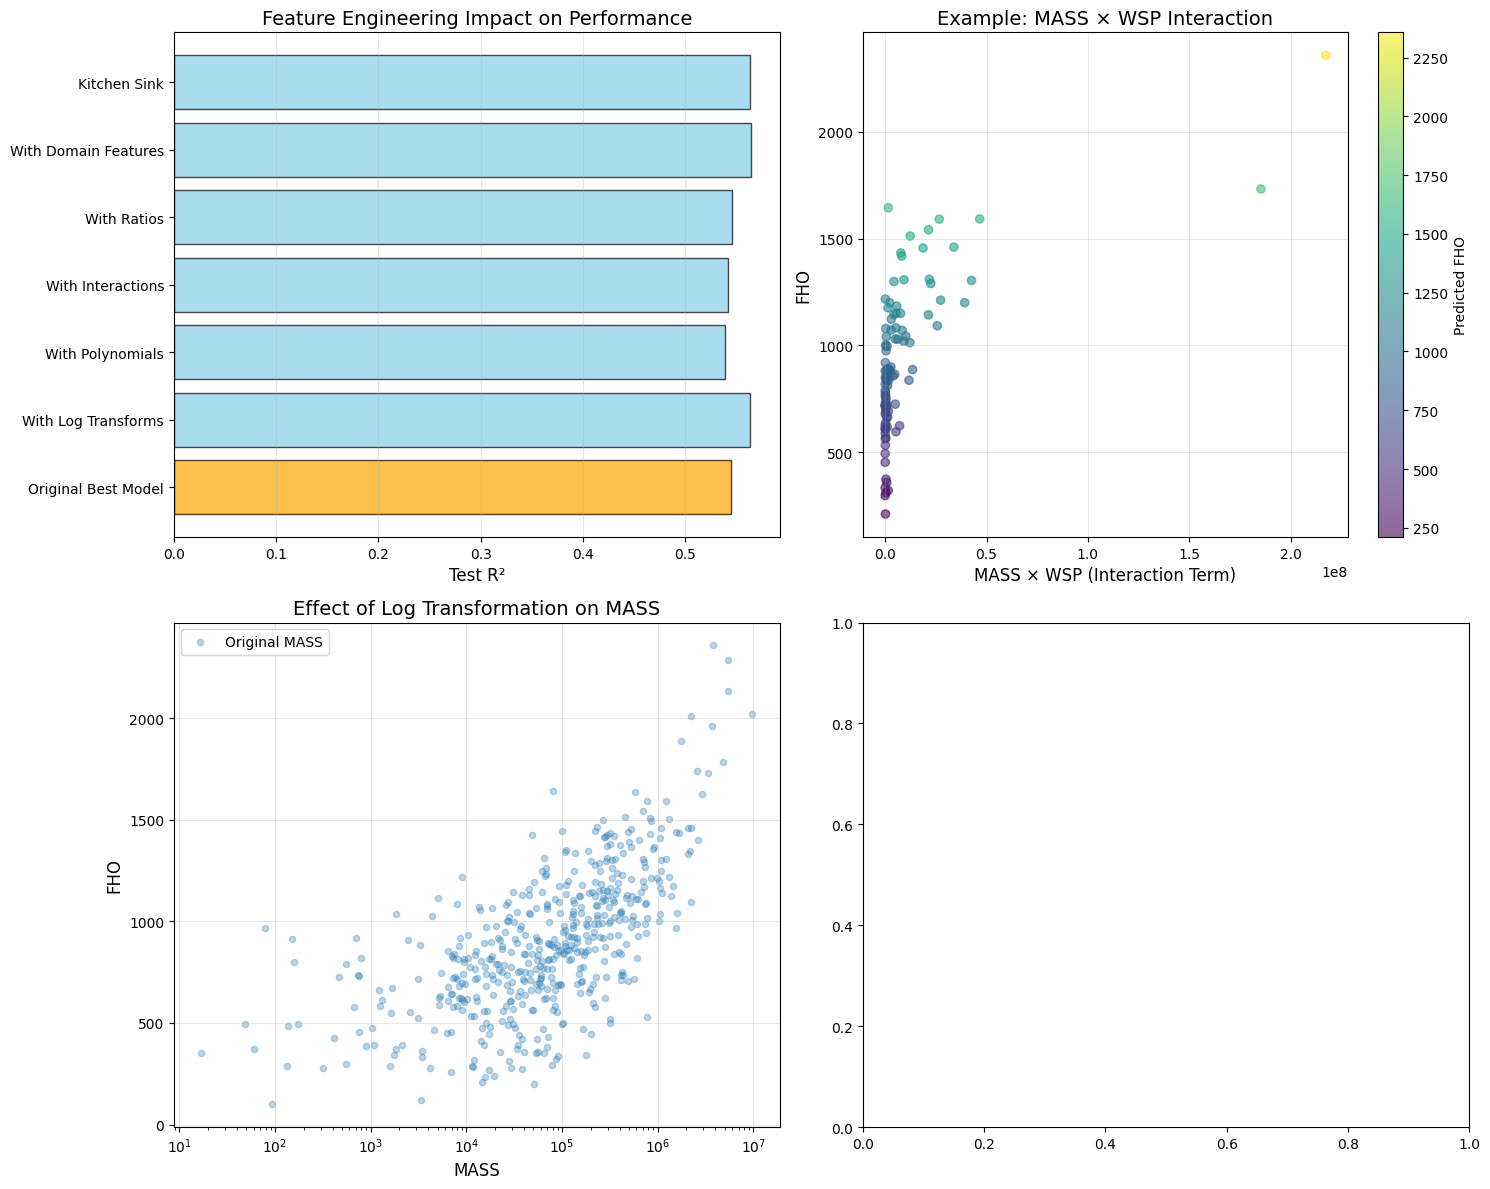


--------------------------------------------------------------------------------
Detailed analysis of engineered features
--------------------------------------------------------------------------------

1. Log transformations:
   Purpose: Handle skewed distributions, reduce impact of outliers
   When to use: Variables with high skewness (>1 or <-1)
   MASS correlation with FHO: 0.5845
   log_MASS correlation with FHO: 0.6457
   → Improvement!

2. Interaction terms:
   Purpose: Capture combined effects of multiple variables
   Example: MASS × WSP might represent total flame capacity
   MASS × WSP correlation with FHO: 0.5021

3. Ratio features:
   Purpose: Capture efficiency or density measures
   MASS/WSP (body density) correlation: 0.6678

4. Domain-specific features:
   Purpose: Incorporate biological knowledge
   Flame power index correlation: 0.5015


In [ ]:
print("\n" + "-"*80)
print("Feature engineering")
print("-"*80)

# Create engineered features
df_engineered = df.copy()

# --- Data Cleaning for Feature Engineering ---
# Address the negative AGE values found during initial exploration
# Replace negative ages with 0 as they are likely data entry errors
df_engineered['AGE'] = np.where(df_engineered['AGE'] < 0, 0, df_engineered['AGE'])

# 1. Log transformations (for skewed variables)
print("\nChecking skewness of variables (after initial cleaning):")
for col in ['MASS', 'AGE', 'WSP']:
    # Use df_engineered for skewness calculation after fixing AGE
    skewness_before_log = df_engineered[col].skew()
    print(f"  {col}: {skewness_before_log:.2f}")
    if abs(skewness_before_log) > 1:
        # Apply log1p on the cleaned/modified df_engineered column
        df_engineered[f'log_{col}'] = np.log1p(df_engineered[col])
        print(f"    → Created log_{col} (skewness reduced to {df_engineered[f'log_{col}'].skew():.2f})")

# 2. Polynomial features
df_engineered['WSP_squared'] = df_engineered['WSP'] ** 2
df_engineered['AGE_squared'] = df_engineered['AGE'] ** 2

# 3. Interaction terms
df_engineered['MASS_x_WSP'] = df_engineered['MASS'] * df_engineered['WSP']
df_engineered['AGE_x_MASS'] = df_engineered['AGE'] * df_engineered['MASS']
df_engineered['WSP_x_SPD'] = df_engineered['WSP'] * df_engineered['SPD']
df_engineered['MASS_x_HID'] = df_engineered['MASS'] * df_engineered['HID']

# 4. Ratio features
df_engineered['MASS_per_WSP'] = df_engineered['MASS'] / (df_engineered['WSP'] + 0.1)  # mass efficiency
df_engineered['SPD_per_MASS'] = df_engineered['SPD'] / (df_engineered['MASS'] + 1)  # power-to-weight ratio

# 5. Domain-specific features
# "Flame power index" - combining age and physical features
df_engineered['flame_power_index'] = (df_engineered['AGE'] * df_engineered['MASS']) / (df_engineered['WSP'] + 1)

# Body Mass Index equivalent for dragons
df_engineered['dragon_BMI'] = df_engineered['MASS'] / (df_engineered['WSP'] ** 2 + 0.1)

# Create dummies for species
df_eng_with_species = pd.get_dummies(df_engineered, columns=['SPC'], drop_first=True)

print("\n" + "-"*80)
print(f"Original features: {len(df.columns)}")
print(f"Engineered features: {len(df_eng_with_species.columns)}")
print(f"New features created: {len(df_eng_with_species.columns) - len(df.columns)}")

# Test different feature combinations
X_eng = df_eng_with_species.drop('FHO', axis=1)
y_eng = df_eng_with_species['FHO']

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42
)

# Test configurations with engineered features
engineered_configs = {
    'Original Best Model': best_features,
    'With Log Transforms': best_features + [f'log_{col}' for col in ['MASS', 'AGE', 'WSP']
                                             if f'log_{col}' in X_eng.columns],
    'With Polynomials': best_features + ['WSP_squared', 'AGE_squared'],
    'With Interactions': best_features + ['MASS_x_WSP', 'AGE_x_MASS', 'WSP_x_SPD'],
    'With Ratios': best_features + ['MASS_per_WSP', 'SPD_per_MASS'],
    'With Domain Features': best_features + ['flame_power_index', 'dragon_BMI'],
    'Kitchen Sink': [col for col in X_eng.columns if col != 'FHO'][:15],  # Top 15 features
}

engineered_results = {}

for config_name, features in engineered_configs.items():
    # Filter features that exist
    available_features = [f for f in features if f in X_train_eng.columns]

    if len(available_features) == 0:
        continue

    X_train_config = X_train_eng[available_features]
    X_test_config = X_test_eng[available_features]

    model = LinearRegression()
    model.fit(X_train_config, y_train_eng)

    y_train_pred = model.predict(X_train_config)
    y_test_pred = model.predict(X_test_config)

    train_r2 = r2_score(y_train_eng, y_train_pred)
    test_r2 = r2_score(y_test_eng, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test_eng, y_test_pred))

    engineered_results[config_name] = {
        'n_features': len(available_features),
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'overfitting': train_r2 - test_r2
    }

# Display results
print("\n" + "-"*80)
print("FEATURE ENGINEERING RESULTS")
print("-"*80)

eng_comparison = pd.DataFrame({
    name: {
        'N Features': results['n_features'],
        'Train R²': results['train_r2'],
        'Test R²': results['test_r2'],
        'RMSE': results['test_rmse'],
        'Overfit Gap': results['overfitting']
    }
    for name, results in engineered_results.items()
}).T

print(eng_comparison.round(4))

# Find improvement
baseline_r2 = engineered_results['Original Best Model']['test_r2']
best_eng_name = max([k for k in engineered_results.keys() if k != 'Original Best Model'],
                    key=lambda x: engineered_results[x]['test_r2'])
best_eng_r2 = engineered_results[best_eng_name]['test_r2']
improvement = best_eng_r2 - baseline_r2

print(f"\n" + "-"*80)
print(f"Best engineered model: {best_eng_name}")
print(f"Improvement over baseline: {improvement:+.4f} ({improvement/baseline_r2*100:+.2f}%)")
print("-"*80)

# Visualize impact
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Performance comparison
ax1 = axes[0, 0]
model_names = list(engineered_results.keys())
test_r2_vals = [engineered_results[m]['test_r2'] for m in model_names]
colors_bars = ['orange' if m == 'Original Best Model' else 'skyblue' for m in model_names]
bars = ax1.barh(model_names, test_r2_vals, color=colors_bars, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Test R²', fontsize=12)
ax1.set_title('Feature Engineering Impact on Performance', fontsize=14)
ax1.grid(True, alpha=0.3, axis='x')

# 2. Scatter plot showing improvement
ax2 = axes[0, 1]
if 'MASS_x_WSP' in X_test_eng.columns:
    scatter = ax2.scatter(X_test_eng['MASS_x_WSP'], y_test_eng,
                         c=y_test_pred if 'With Interactions' in best_eng_name else y_test_eng,
                         alpha=0.6, cmap='viridis')
    ax2.set_xlabel('MASS × WSP (Interaction Term)', fontsize=12)
    ax2.set_ylabel('FHO', fontsize=12)
    ax2.set_title('Example: MASS × WSP Interaction', fontsize=14)
    plt.colorbar(scatter, ax=ax2, label='Predicted FHO')
    ax2.grid(True, alpha=0.3)

# 3. Log transformation effect
ax3 = axes[1, 0]
if 'log_MASS' in df_engineered.columns:
    ax3.scatter(df_engineered['MASS'], df_engineered['FHO'], alpha=0.3, label='Original MASS', s=20)
    ax3.set_xlabel('MASS', fontsize=12)
    ax3.set_ylabel('FHO', fontsize=12)
    ax3.set_title('Effect of Log Transformation on MASS', fontsize=14)
    ax3.set_xscale('log')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 4. Feature importance (if using interaction model)
ax4 = axes[1, 1]
if best_eng_name == 'With Interactions':
    interaction_features = ['MASS_x_WSP', 'AGE_x_MASS', 'WSP_x_SPD']
    available_int = [f for f in interaction_features if f in X_train_eng.columns]

    if available_int:
        # Fit model with interactions
        all_features = best_features + available_int
        X_for_importance = X_train_eng[[f for f in all_features if f in X_train_eng.columns]]

        model_int = LinearRegression()
        model_int.fit(X_for_importance, y_train_eng)

        # Get standardized coefficients
        scaler_int = StandardScaler()
        X_scaled_int = scaler_int.fit_transform(X_for_importance)
        model_scaled_int = LinearRegression()
        model_scaled_int.fit(X_scaled_int, y_train_eng)

        importance_df = pd.DataFrame({
            'Feature': X_for_importance.columns,
            'Importance': np.abs(model_scaled_int.coef_)
        }).sort_values('Importance', ascending=True).tail(10)

        colors_imp = ['red' if 'x' in f else 'blue' for f in importance_df['Feature']]
        ax4.barh(importance_df['Feature'], importance_df['Importance'],
                color=colors_imp, alpha=0.7)
        ax4.set_xlabel('Absolute Standardized Coefficient', fontsize=12)
        ax4.set_title('Top 10 Feature Importances\n(Red = Interactions)', fontsize=14)
        ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_engineering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Detailed analysis of best engineered feature
print("\n" + "-"*80)
print("Detailed analysis of engineered features")
print("-"*80)

print("\n1. Log transformations:")
print("   Purpose: Handle skewed distributions, reduce impact of outliers")
print("   When to use: Variables with high skewness (>1 or <-1)")
if 'log_MASS' in df_engineered.columns:
    correlation_original = df['MASS'].corr(df['FHO'])
    correlation_log = df_engineered['log_MASS'].corr(df_engineered['FHO'])
    print(f"   MASS correlation with FHO: {correlation_original:.4f}")
    print(f"   log_MASS correlation with FHO: {correlation_log:.4f}")
    print(f"   → {'Improvement!' if abs(correlation_log) > abs(correlation_original) else 'No improvement'}")

print("\n2. Interaction terms:")
print("   Purpose: Capture combined effects of multiple variables")
print("   Example: MASS × WSP might represent total flame capacity")
if 'MASS_x_WSP' in df_engineered.columns:
    corr_interaction = df_engineered['MASS_x_WSP'].corr(df_engineered['FHO'])
    print(f"   MASS × WSP correlation with FHO: {corr_interaction:.4f}")

print("\n3. Ratio features:")
print("   Purpose: Capture efficiency or density measures")
if 'MASS_per_WSP' in df_engineered.columns:
    corr_ratio = df_engineered['MASS_per_WSP'].corr(df_engineered['FHO'])
    print(f"   MASS/WSP (body density) correlation: {corr_ratio:.4f}")

print("\n4. Domain-specific features:")
print("   Purpose: Incorporate biological knowledge")
if 'flame_power_index' in df_engineered.columns:
    corr_power = df_engineered['flame_power_index'].corr(df_engineered['FHO'])
    print(f"   Flame power index correlation: {corr_power:.4f}")